[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\samiu\AppData\Roaming\nltk_data...
C:\Users\samiu\Documents\anc 11\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0909 - loss: 1.6234
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1818 - loss: 1.5994
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0909 - loss: 1.6453
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0909 - loss: 1.6562    
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3636 - loss: 1.5876
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3636 - loss: 1.5601    
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5455 - loss: 1.5343
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7273 - loss: 1.4742
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3636 - loss: 1.5392
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5455 - loss: 1.4374
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3636 - loss: 1.4368
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4

Accuracy: 1.0
Loss: 0.0032953100744634867
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

Confusion Matrix:
 [[2 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 2 0]
 [0 0 0 0 2]]

Classification Report:

              precision    recall  f1-score   support

    delivery       1.00      1.00      1.00         2
     goodbye       1.00      1.00      1.00         2
    greeting       1.00      1.00      1.00         3
        menu       1.00      1.00      1.00         2
       order       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



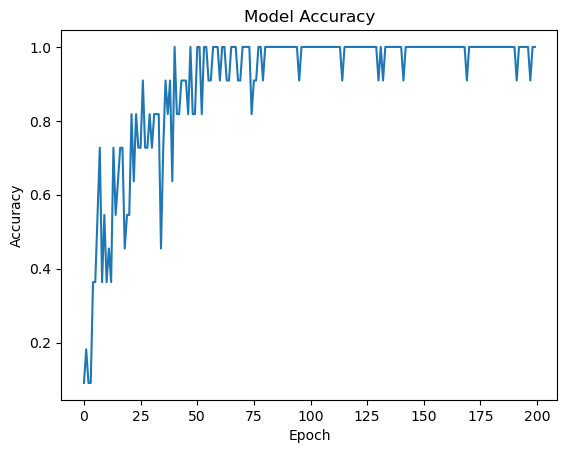

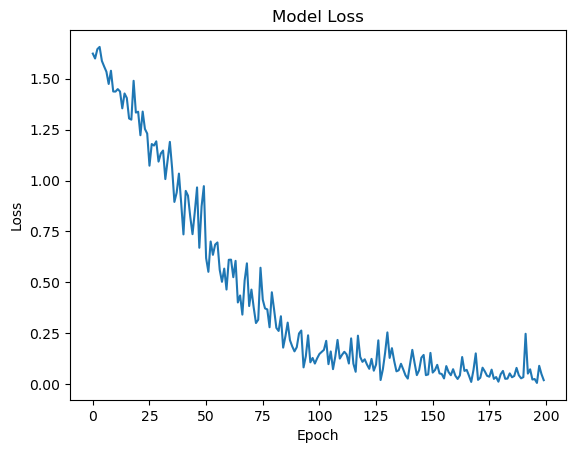

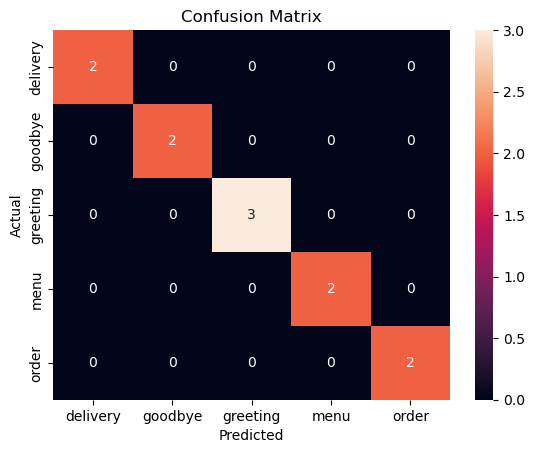

Chatbot is running... Type 'quit' to exit


You:  menu


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Bot: We have Pepperoni, BBQ, Veggie


You:  BBQ


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Bot: Hello!


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Bot: Hi there!


You:  show menu


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Bot: We have Pepperoni, BBQ, Veggie


You:  i want pizza


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Bot: Your order is placed!


In [ ]:
import numpy as np
import random
import nltk
import ssl
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

ssl._create_default_https_context = ssl._create_unverified_context

try:
    nltk.download('wordnet')
except:
    pass

lemmatizer = WordNetLemmatizer()

intents = {
    "intents": [
        {"tag": "greeting", "patterns": ["Hi", "Hello", "Hey"], "responses": ["Hello!", "Hi there!"]},
        {"tag": "menu", "patterns": ["Show menu", "What pizzas do you have"], "responses": ["We have Pepperoni, BBQ, Veggie"]},
        {"tag": "order", "patterns": ["I want pizza", "Order pizza"], "responses": ["Your order is placed!"]},
        {"tag": "delivery", "patterns": ["Delivery time?", "When will it arrive"], "responses": ["30 minutes delivery time"]},
        {"tag": "goodbye", "patterns": ["Bye", "See you"], "responses": ["Goodbye!", "See you later!"]}
    ]
}

words = []
classes = []
documents = []
ignore_letters = ['?', '!', '.', ',']

for intent in intents['intents']:
    for pattern in intent['patterns']:

        word_list = pattern.split()

        words.extend(word_list)
        documents.append((word_list, intent['tag']))

        if intent['tag'] not in classes:
            classes.append(intent['tag'])

words = [
    lemmatizer.lemmatize(word.lower())
    for word in words
    if word not in ignore_letters
]

words = sorted(set(words))
classes = sorted(set(classes))

training = []
output_empty = [0] * len(classes)

for doc in documents:

    bag = []

    word_patterns = [
        lemmatizer.lemmatize(word.lower())
        for word in doc[0]
    ]

    for word in words:
        bag.append(1 if word in word_patterns else 0)

    output_row = list(output_empty)
    output_row[classes.index(doc[1])] = 1

    training.append([bag, output_row])

random.shuffle(training)
training = np.array(training, dtype=object)

train_x = np.array(list(training[:, 0]))
train_y = np.array(list(training[:, 1]))

model = Sequential()

model.add(Dense(128, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(train_y[0]), activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

history = model.fit(
    train_x,
    train_y,
    epochs=200,
    batch_size=5,
    verbose=1
)

model.save('chatbot_model.h5')

loss, accuracy = model.evaluate(train_x, train_y, verbose=0)

print("Accuracy:", accuracy)
print("Loss:", loss)

y_pred = model.predict(train_x)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(train_y, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=classes
))

plt.figure()

plt.plot(history.history['accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

plt.figure()

plt.plot(history.history['loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

def clean_up_sentence(sentence):

    sentence_words = sentence.split()

    sentence_words = [
        lemmatizer.lemmatize(word.lower())
        for word in sentence_words
    ]

    return sentence_words

def bag_of_words(sentence):

    sentence_words = clean_up_sentence(sentence)

    bag = [0] * len(words)

    for w in sentence_words:
        for i, word in enumerate(words):
            if word == w:
                bag[i] = 1

    return np.array(bag)

def predict_class(sentence):

    bow = bag_of_words(sentence)

    res = model.predict(np.array([bow]))[0]

    idx = np.argmax(res)

    return classes[idx]

def get_response(tag):

    for intent in intents['intents']:
        if intent['tag'] == tag:
            return random.choice(intent['responses'])

print("Chatbot is running... Type 'quit' to exit")

while True:

    message = input("You: ")

    if message == "quit":
        break

    tag = predict_class(message)

    response = get_response(tag)

    print("Bot:", response)